# ==================================================
# 📊 PROJETO DE APRENDIZADO - DATA SCIENCE
# ==================================================

"""
Este projeto tem como objetivo praticar análise de dados e entender
o comportamento de clientes em relação à aceitação de empréstimos.

Estou utilizando este projeto como forma de aprendizado em Data Science,
com apoio de IA para entender melhor os conceitos e estruturar o código.
"""

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('/content/Bank_Personal_Loan_Modelling.csv')

print("Shape:", df.shape)
df.head()

Shape: (5000, 14)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [3]:
print(df.isnull().sum())


ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


In [4]:
print("Duplicados", df.duplicated().sum())

Duplicados 0


In [5]:
df = df.drop(['ID', 'ZIP Code'], axis=1)

Aqui observo média, mínimo, máximo
Tento entender comportamento geral dos dados


In [6]:
df.describe()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.467954,46.033729,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,-3.000000,8.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


A maioria dos clientes não aceita empréstimo, o que indica que o banco pode estar oferecendo para muitas pessoas sem interesse.

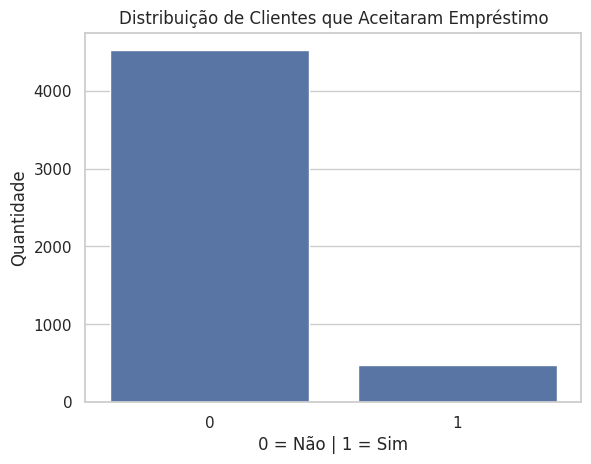

In [11]:
plt.figure()
sns.countplot(x='Personal Loan', data=df)

plt.title('Distribuição de Clientes que Aceitaram Empréstimo')
plt.xlabel('0 = Não | 1 = Sim')
plt.ylabel('Quantidade')

plt.show()

Algumas variáveis como renda (Income) parecem ter relação maior com a aceitação do empréstimo.

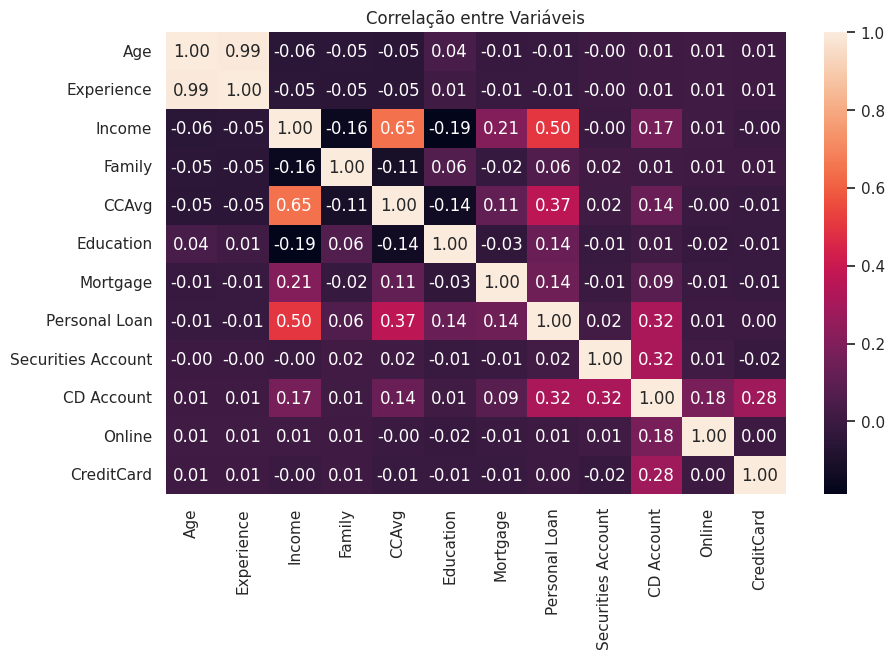

In [12]:
plt.figure(figsize=(10,6))

correlation = df.corr()

sns.heatmap(correlation, annot=True, fmt=".2f")

plt.title('Correlação entre Variáveis')

plt.show()

Clientes que aceitam empréstimo tendem a ter renda maior.

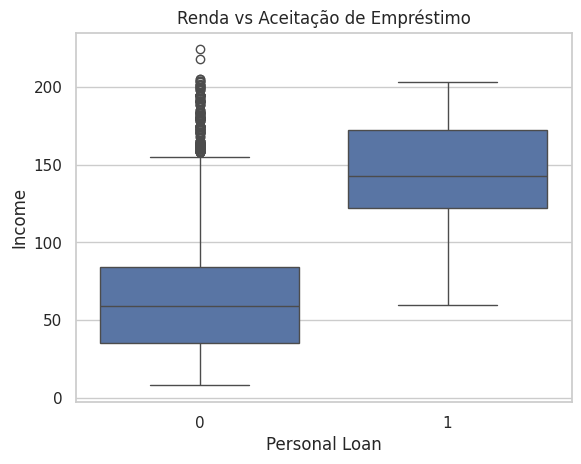

In [13]:
plt.figure()

sns.boxplot(x='Personal Loan', y='Income', data=df)

plt.title('Renda vs Aceitação de Empréstimo')

plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Personal Loan', axis=1)
y = df['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

Estou usando accuracy apenas para entender o desempenho inicial.

In [15]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.988


Renda e gastos parecem ser importantes para prever a decisão.

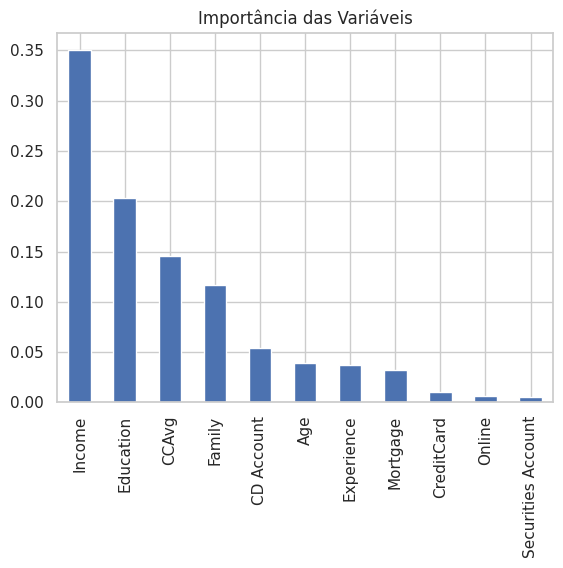

In [16]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar')

plt.title('Importância das Variáveis')
plt.show()

Esta é uma simulação simples apenas para entender o impacto do modelo.

In [17]:
df['probabilidade'] = model.predict_proba(X)[:,1]

threshold = 0.5
df['target_pred'] = (df['probabilidade'] >= threshold).astype(int)

clientes = df[df['target_pred'] == 1]

receita = 2000
custo = 50

if len(clientes) > 0:
    taxa = clientes['Personal Loan'].mean()
    lucro = len(clientes) * receita * taxa - len(clientes) * custo
else:
    lucro = 0

print("Lucro estimado:", lucro)

Lucro estimado: 918350.0


O lucro varia conforme o critério de decisão, mostrando que o modelo pode ajudar a melhorar campanhas.

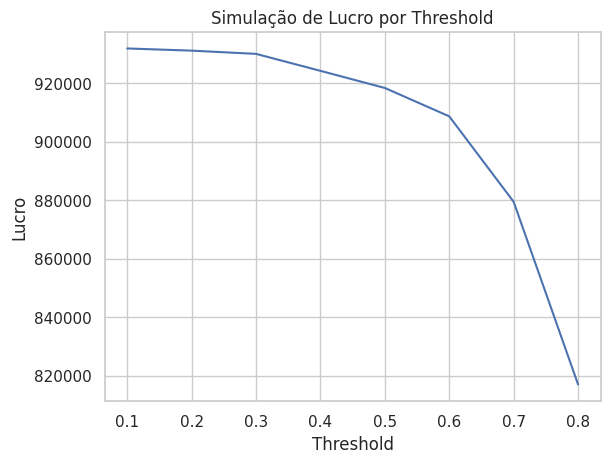

In [18]:
thresholds = np.arange(0.1, 0.9, 0.1)
lucros = []

for t in thresholds:
    df['target_pred'] = (df['probabilidade'] >= t).astype(int)
    clientes = df[df['target_pred'] == 1]

    if len(clientes) > 0:
        taxa = clientes['Personal Loan'].mean()
        lucro = len(clientes) * receita * taxa - len(clientes) * custo
    else:
        lucro = 0

    lucros.append(lucro)

plt.figure()
plt.plot(thresholds, lucros)

plt.title('Simulação de Lucro por Threshold')
plt.xlabel('Threshold')
plt.ylabel('Lucro')

plt.show()

In [19]:
plt.savefig('/content/grafico.png')

<Figure size 640x480 with 0 Axes>